
CAGR formula = (NAV_end / NAV_start) ^ (1/years) - 1

# Phase 3: EDA & Feature Engineering

Computed real CAGR, rolling CAGR, and volatility (std dev) from actual 
NAV history for all 6 funds, replacing the placeholder rates used in 
Phase 2's baseline.

## What was built
- `calculate_cagr()` — full-period CAGR from first to last NAV
- `calculate_rolling_cagr()` — CAGR for every possible N-year window in 
  a fund's history, using actual calendar dates (not row-count 
  approximation) to correctly handle non-trading days
- Risk/return summary table and scatter plot (5yr rolling windows)
- Multi-horizon comparison across 1/3/5/7/10-year windows

## Key findings
- Replacing Phase 2's guessed rates with real CAGR changed the 
  recommended "best" fund from sbi_large_cap to icici_large_cap — 
  proof the static baseline could recommend a suboptimal option.
- Corporate bond funds show low, flat volatility regardless of holding 
  period (~1% std). Equity fund volatility drops sharply as holding 
  period increases (e.g. hdfc_large_cap: ~20% std at 1yr -> ~2-5% std 
  at 5-10yr).
- Worst-case (min) rolling return for equity funds improves 
  dramatically with longer holding periods — e.g. hdfc_large_cap's 
  worst 1-year window was -37%, but no 7+ year window in this dataset 
  was ever negative. This is the core evidence for why holding period 
  should influence recommendations.
- Mean rolling CAGR for equity funds shows a "dip then recovery" 
  pattern across window lengths (high at 1yr, lowest around 5-7yr, 
  ticks back up at 10yr). Likely driven by which specific historical 
  periods each window length happens to average over — not fully 
  explained, noted as an observation.
- icici_large_cap was consistently the top or near-top performer 
  across every

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt



In [3]:
fund_names = ['hdfc_large_cap', 'hdfc_corporate_bond', 'hdfc_hybrid_equity',
              'sbi_large_cap', 'icici_large_cap', 'icici_corporate_bond']

data = {} # all csv data is stored in here to access in python

for name in fund_names:
    df = pd.read_csv(f"../Data/raw/{name}.csv")
    df['date'] = pd.to_datetime(df['date']) # converts string value in db to datetime object
    data[name] = df

print(data.keys())

dict_keys(['hdfc_large_cap', 'hdfc_corporate_bond', 'hdfc_hybrid_equity', 'sbi_large_cap', 'icici_large_cap', 'icici_corporate_bond'])


In [4]:
def calculate_cagr(df):
    nav_start = df['nav'].iloc[0]
    nav_end = df['nav'].iloc[-1]

    date_start = df['date'].iloc[0]
    date_end = df['date'].iloc[-1]

    years = (date_end - date_start).days / 365.25 # accounting for leap years

    return (nav_end / nav_start )**(1/years) -1
'''One small thing worth noting: you'll see np.float64(...) wrapping every number instead of a plain 
float like 0.1322.... That's just numpy's own float type — pandas operations (like .iloc, division, **)
 tend to return numpy types rather than pure Python floats under the hood. Functionally it behaves 
 identically to a regular float in all your math and comparisons; it's just how it displays when 
 printed raw inside a dict. Nothing to fix.'''


"One small thing worth noting: you'll see np.float64(...) wrapping every number instead of a plain \nfloat like 0.1322.... That's just numpy's own float type — pandas operations (like .iloc, division, **)\n tend to return numpy types rather than pure Python floats under the hood. Functionally it behaves \n identically to a regular float in all your math and comparisons; it's just how it displays when \n printed raw inside a dict. Nothing to fix."

In [5]:
# print(calculate_cagr(data['hdfc_large_cap']))
real_rates = {}

for name, df in data.items():
    real_rates[name] = calculate_cagr(df)

print(real_rates)

{'hdfc_large_cap': np.float64(0.1322356312756625), 'hdfc_corporate_bond': np.float64(0.07970769495864638), 'hdfc_hybrid_equity': np.float64(0.11361766804856166), 'sbi_large_cap': np.float64(0.14459174060950164), 'icici_large_cap': np.float64(0.1473384306277543), 'icici_corporate_bond': np.float64(0.08117463419010562)}


In [6]:
import sys
sys.path.append('../src')
from calculators import compound_interest, recommend_best


In [7]:
results, best = recommend_best(10000,10, real_rates)
print(results)
print("Best: ",best)

{'hdfc_large_cap': np.float64(34623.2777280208), 'hdfc_corporate_bond': np.float64(21530.88917479742), 'hdfc_hybrid_equity': np.float64(29333.31364923049), 'sbi_large_cap': np.float64(38592.78118463047), 'icici_large_cap': np.float64(39528.9617233331), 'icici_corporate_bond': np.float64(21825.212462677417)}
Best:  icici_large_cap


In [8]:
# def calculate_rolling_cagr(df, window_years):
#     df =df.copy()
#     df = df.set_index('date')

#     window_days = int(window_years * 365.25)
#     rolling_cagr = []
#     dates = []
#     # goes day by day that what would be the cagr for this date to 5 yr ahead.
#     for i in range(len(df) - window_days):
#         start_nav = df['nav'].iloc[i]
#         end_nav = df['nav'].iloc[i + window_days]
#         cagr = (end_nav/start_nav)**(1/window_years) -1
#         rolling_cagr.append(cagr)
#         dates.append(df.index[i])
#     return pd.Series(rolling_cagr, dates)

def calculate_rolling_cagr(df, window_years):
    df =df.copy()
    df = df.set_index('date')

    rolling_cagr = []
    dates = []

    for i in range(len(df)):
        start_date = df.index[i]
        # dateoffset shifts in acctual calendar years so data is acctually year wise
        target_end_date = start_date + pd.DateOffset(years = window_years)

        if(target_end_date>df.index[-1]):
            break
        # searchsorted does a binary search an return the closest date available near target
        end_idx = df.index.searchsorted(target_end_date)

        start_nav = df['nav'].iloc[i]
        end_nav = df['nav'].iloc[end_idx]

        acctual_years = (df.index[end_idx] - start_date).days/365.25
        cagr = (end_nav /start_nav)**(1/acctual_years) -1
        rolling_cagr.append(cagr)
        dates.append(start_date)
    return pd.Series(rolling_cagr , index = dates)









this window this by days wont work as it assumes that trade happens 365 days a year which is not true. so 10 year give us nan and doesnt work. TO PREVENT THIS WE'LL HAVE TO SHIFT FROM USING DAYS TO USING ACCTUAL DATES:

In [9]:
rolling_data = calculate_rolling_cagr(data['hdfc_large_cap'], 5)
# print(rolling_data.head())'
# print(rolling_data.tail())'
print(rolling_data.describe())

count    2100.000000
mean        0.141421
std         0.049078
min        -0.014501
25%         0.112769
50%         0.144020
75%         0.168349
max         0.295082
dtype: float64


In [10]:
summary =[]
for name, df in data.items():
    rolling = calculate_rolling_cagr(df, 5)
    summary.append({
        'fund' : name,
        "std" : rolling.std(),
        'mean' : rolling.mean(),
        'min' : rolling.min(),
        'max': rolling.max()
    })
summary_df = pd.DataFrame(summary)
print(summary_df)

                   fund       std      mean       min       max
0        hdfc_large_cap  0.049078  0.141421 -0.014501  0.295082
1   hdfc_corporate_bond  0.008807  0.078948  0.060465  0.094079
2    hdfc_hybrid_equity  0.046076  0.123799 -0.011455  0.241178
3         sbi_large_cap  0.042789  0.146397 -0.002352  0.276756
4       icici_large_cap  0.046533  0.154617  0.000133  0.303411
5  icici_corporate_bond  0.007494  0.078765  0.065429  0.091061


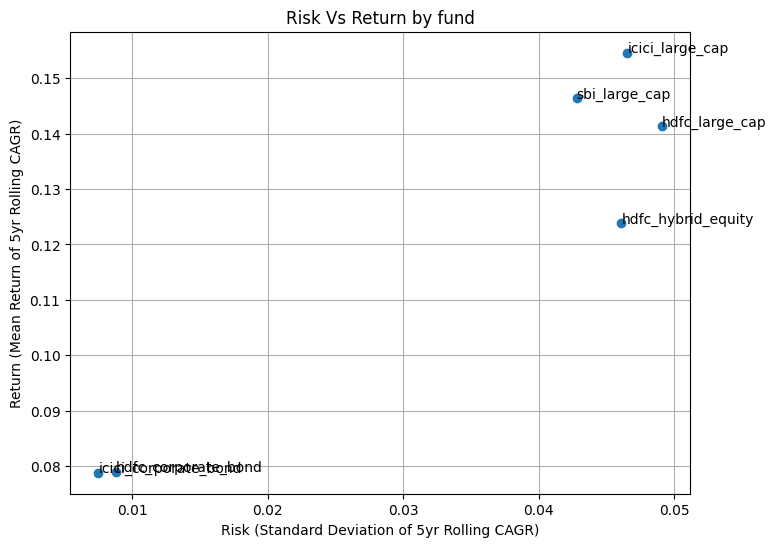

In [11]:
plt.figure(figsize=(8,6))
# scatter is used to show individual points instead of lines.
plt.scatter(summary_df['std'], summary_df['mean'])
# annotate labels those individual points. if u dont u'll see 6 unlabeled dots with no way of differentiating them
for i in range(len(summary_df)):
    plt.annotate(summary_df['fund'].iloc[i],(summary_df['std'].iloc[i], summary_df['mean'].iloc[i]))


plt.xlabel('Risk (Standard Deviation of 5yr Rolling CAGR)')
plt.ylabel('Return (Mean Return of 5yr Rolling CAGR)')
plt.title('Risk Vs Return by fund')
plt.grid(True)
plt.show()

NOW WE HAVE A SUMMARY OF A 5 YR WINDOW. BUT A CUSTOMER WILL NOT ALWAYS BE INVESTING IN A 5 YR WINDOW. IT FLEXIBLE SO WE NEED MORE OPTIONS AND MORE REAILABILITY. SO WE'LL CALCULATE ROLLING CAGR FOR 1 3 5 7 10 YR AND GIVE AS REAILABLE OP AS POSSIBLE

In [12]:
window_list = [x for x in range(1,11)]
all_summary = []

for window in window_list:
    for name, df in data.items():
        rolling = calculate_rolling_cagr(df, window)
        all_summary.append({
            'fund' : name,
            'window_years' : window,
            'std' : rolling.std(),
            'mean': rolling.mean(),
            'min' : rolling.min(),
            'max': rolling.max()
        })
all_summary_df = pd.DataFrame(all_summary)
print(all_summary_df)    

                    fund  window_years       std      mean       min       max
0         hdfc_large_cap             1  0.202796  0.165908 -0.370503  0.909686
1    hdfc_corporate_bond             1  0.025449  0.080809  0.017989  0.132758
2     hdfc_hybrid_equity             1  0.200889  0.151122 -0.262422  0.893053
3          sbi_large_cap             1  0.179314  0.169904 -0.303183  0.981667
4        icici_large_cap             1  0.177664  0.174532 -0.315764  0.928822
5   icici_corporate_bond             1  0.020733  0.081429  0.030581  0.121001
6         hdfc_large_cap             2  0.097973  0.150383 -0.150148  0.503582
7    hdfc_corporate_bond             2  0.018909  0.080870  0.038043  0.118014
8     hdfc_hybrid_equity             2  0.097000  0.133907 -0.130787  0.454401
9          sbi_large_cap             2  0.093568  0.158834 -0.144813  0.506684
10       icici_large_cap             2  0.091915  0.163715 -0.137818  0.522847
11  icici_corporate_bond             2  0.015987  0.

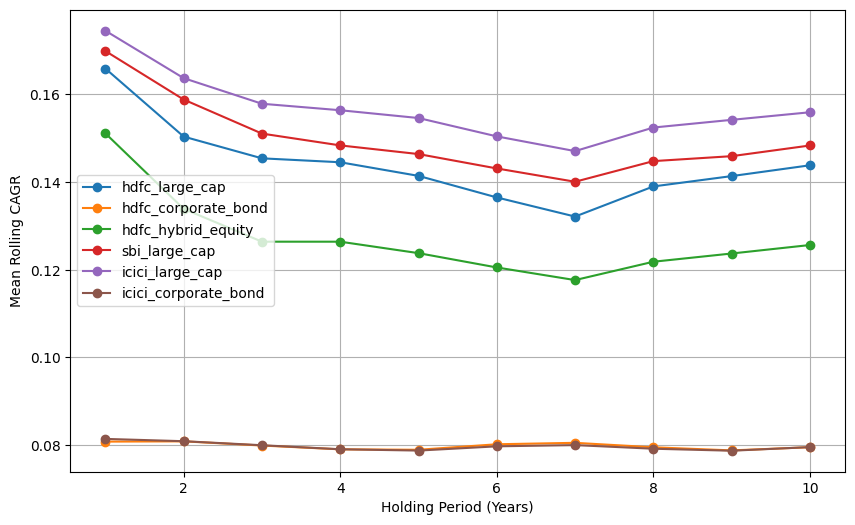

In [13]:
plt.figure(figsize = (10,6))

for name in fund_names:
    fund_data = all_summary_df[all_summary_df['fund'] == name]
    # plot used lines to connet. marker is the icon u see at values, label is used to give names
    # to the box [legend is used to form that box] u see
    plt.plot(fund_data['window_years'], fund_data['mean'], marker = 'o', label = name)
plt.xlabel('Holding Period (Years)')
plt.ylabel('Mean Rolling CAGR')
plt.legend()
plt.grid(True)
plt.show()



In [14]:
long_data = []

for name, df in data.items():
    for window in  window_list:
        rolling = calculate_rolling_cagr(df, window)
        for date, rolling_cagr in rolling.items():
            long_data.append({
                'fund' : name,
                'window_years' : window,
                'start_date': date,
                'cagr' : rolling_cagr
            })

long_df = pd.DataFrame(long_data)
print(long_df.shape)
print(long_df.head())

(117804, 4)
             fund  window_years start_date      cagr
0  hdfc_large_cap             1 2013-01-01  0.034098
1  hdfc_large_cap             1 2013-01-02  0.007658
2  hdfc_large_cap             1 2013-01-03  0.006140
3  hdfc_large_cap             1 2013-01-04  0.001175
4  hdfc_large_cap             1 2013-01-07 -0.003395


The lower part was done because we the 'fund' name is a txt and regression model works on number to give a number output. the get dummies part splits the funds by 0 1 so that model can know which fund it is calculting about. Also the raw start date is also use less as is so we'll also be converting it here or there into someting useful

Also python treats boolen as a subtype of integers so the true false will not cause an issue when we later feed it into the model

In [15]:
long_df_encoded = pd.get_dummies(long_df, columns = ['fund'])
print(long_df_encoded.head())
print(long_df_encoded.columns)

   window_years start_date      cagr  fund_hdfc_corporate_bond  \
0             1 2013-01-01  0.034098                     False   
1             1 2013-01-02  0.007658                     False   
2             1 2013-01-03  0.006140                     False   
3             1 2013-01-04  0.001175                     False   
4             1 2013-01-07 -0.003395                     False   

   fund_hdfc_hybrid_equity  fund_hdfc_large_cap  fund_icici_corporate_bond  \
0                    False                 True                      False   
1                    False                 True                      False   
2                    False                 True                      False   
3                    False                 True                      False   
4                    False                 True                      False   

   fund_icici_large_cap  fund_sbi_large_cap  
0                 False               False  
1                 False               Fals

Since start date isnt acc usefull to us directly or indiretly for the outcome we want we'll drop it

In [16]:
model_df = long_df_encoded.drop(columns = ['start_date'])
print(model_df.head())
print(model_df.columns)

   window_years      cagr  fund_hdfc_corporate_bond  fund_hdfc_hybrid_equity  \
0             1  0.034098                     False                    False   
1             1  0.007658                     False                    False   
2             1  0.006140                     False                    False   
3             1  0.001175                     False                    False   
4             1 -0.003395                     False                    False   

   fund_hdfc_large_cap  fund_icici_corporate_bond  fund_icici_large_cap  \
0                 True                      False                 False   
1                 True                      False                 False   
2                 True                      False                 False   
3                 True                      False                 False   
4                 True                      False                 False   

   fund_sbi_large_cap  
0               False  
1               Fals

<!-- TODO: SEPERATING INPUT X AND TARGET(PREDICTION) Y -->

In [17]:
x= model_df.drop(columns =['cagr'])
y = model_df['cagr']
# quantile is take x% of y for datetime type objext
cutoff_date = long_df_encoded['start_date'].quantile(.8)
print(x.shape)
print(y.shape)
print(cutoff_date)

(117804, 7)
(117804,)
2020-05-20 00:00:00


In [18]:
train_dates = long_df_encoded['start_date']< cutoff_date 
test_dates = long_df_encoded['start_date'] >= cutoff_date

x_train, x_test = x[train_dates] , x[test_dates]
y_train, y_test = y[train_dates], y[test_dates]

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(94230, 7) (23574, 7)
(94230,) (23574,)


In [19]:
!pip install scikit-learn


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0. ,-0.04, 0. ,...,-0.04, 0.03, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['window_years','fund_hdfc_corporate_bond','fund_hdfc_hybrid_equity',..., 'fund_icici_corporate_bond','fund_icici_large_cap','fund_sbi_large_cap']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.124
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [21]:
print(x.columns.tolist)
print(model.coef_)

print(model.intercept_)

<bound method IndexOpsMixin.tolist of Index(['window_years', 'fund_hdfc_corporate_bond', 'fund_hdfc_hybrid_equity',
       'fund_hdfc_large_cap', 'fund_icici_corporate_bond',
       'fund_icici_large_cap', 'fund_sbi_large_cap'],
      dtype='str')>
[-0.00077221 -0.03659973  0.00304254  0.014573   -0.03736511  0.02870923
  0.02764006]
0.12399917431540096


In [22]:
y_pred = model.predict(x_test)


In [23]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mae: ', mae)
print('r2: ', r2)

Mae:  0.056740769744004306
r2:  0.17413878955319595


Phase 4a: Baseline Linear Regression — Results & Analysis
Setup: Trained on long_df (117,804 rolling-window CAGR rows across 6 funds, window_years 1–10), one-hot encoded by fund, split 80/20 by start_date (time-based split, not random, to avoid leaking near-duplicate overlapping windows between train and test).
Results:

MAE: 0.0567 (predictions off by ~5.7 percentage points of CAGR on average)
R²: 0.174 (model explains ~17% of the variation in actual CAGR)

Why it's okay as a baseline:

It correctly ranks the funds in a way that's consistent with Phase 3's EDA — icici_large_cap and sbi_large_cap come out with the highest coefficients, hdfc_corporate_bond and icici_corporate_bond the lowest, matching the equity-vs-bond return pattern already observed.
It confirms the pipeline (data → features → split → train → evaluate) works end-to-end before adding complexity — useful as a reference point to measure future models against.

Why it fails / known limitations:

window_years coefficient is near-zero (-0.00077). The model has effectively learned that holding period barely affects predicted CAGR at all. This contradicts Phase 3's finding of a "dip then recovery" pattern in CAGR across window lengths, and the finding that equity funds show sharply reduced downside risk at longer horizons.
Root cause: Linear Regression cannot represent interaction effects. It assumes each feature (fund, window_years) affects CAGR independently and additively. In reality, the effect of holding period likely depends on which fund it is — e.g. an equity fund may need years to recover from short-term dips while a bond fund's return stays flat regardless of horizon. Since the model has no way to represent "fund A behaves differently over time than fund B," it averages this variation away, which shows up as the flat window_years coefficient.
Practical consequence: because holding period barely moves the prediction, the model's fund ranking is nearly static — it would recommend the same 1–2 funds (icici_large_cap, sbi_large_cap) almost regardless of the number of years input by the user. This defeats the actual purpose of an investment advisor tool, which should ideally recommend different funds for different time horizons and risk profiles.
Dummy variable trap: all 6 fund columns were kept during one-hot encoding (none dropped as baseline via drop_first=True), so individual fund coefficients and the intercept are not uniquely identifiable — only their relative ordering is meaningful. Noted as a data-prep fix for future iterations, though it doesn't affect predictions themselves.

Conclusion: Linear Regression is too structurally simple for this problem — the real relationship between fund, holding period, and return appears non-linear, with time-dependent behavior that differs per fund. This motivates trying a model that can learn interactions and non-linear patterns natively, e.g. a tree-based model (Random Forest), rather than manually engineering interaction terms into a linear model.

In [24]:
from sklearn.ensemble import RandomForestRegressor
# estimators is no of dictinct trees to use and ranfom state fixes the output like seed in random.integer
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(x_train, y_train)




,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [25]:
y_pred_rf = rf_model.predict(x_test)
mae_rf = mean_absolute_error(y_test,y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('mae: ', mae_rf)
print('r2: ', r2_rf)

mae:  0.05887305311389572
r2:  0.1636818497235215


Phase 4b: Random Forest — Results & Analysis
Setup: Same features (window_years + 6 fund dummies), same time-based 80/20 train/test split as the Linear Regression baseline, for direct comparison. RandomForestRegressor(n_estimators=100, random_state=42).
Results:
MetricLinear RegressionRandom ForestMAE0.05670.0589R²0.1740.164
Random Forest performed slightly worse than the linear baseline on both metrics, despite being a more flexible, non-linear model.
Why the more flexible model didn't help:

Feature space is too small to exploit. With only window_years (10 possible values) and 6 one-hot fund columns, there are just 60 unique (fund, window_years) combinations across all 117,804 rows. Both models are fundamentally limited to learning something close to the average CAGR per bucket — there isn't enough distinct feature information for Random Forest's added flexibility to meaningfully outperform a straight line. The "extra power" had little real signal left to extract.
Likely mild overfitting. With 100 unrestricted trees, Random Forest can fit noise within each bucket's training rows (variation driven by which historical period a window happened to start in — information the model never actually sees, since start_date isn't a feature). This noise doesn't generalize to the test set, and can slightly hurt test performance relative to a simpler model that isn't flexible enough to overfit in the first place.
Train/test split spans a market regime shift. The time-based split trains on ~2013–2020 and tests on ~2020–2026 — a period that includes the COVID crash and recovery. A model trained only on pre-2020 data has no way to anticipate this kind of shock. This affects both models roughly equally and is a genuine limitation of the ~13.5-year dataset (already flagged in Phase 3), not a modeling error.

Conclusion: The bottleneck is not model choice — it's feature information. window_years and fund alone don't carry enough signal to predict CAGR well, regardless of how flexible the model is. This confirms that the previously-logged future extension, "market conditions as a feature" (e.g. macro indicators, rolling market volatility, or time-since-start as a feature), is not just a nice-to-have but likely the actual next lever for improving prediction quality. For the current scope, Linear Regression's marginal edge and interpretability make it the more defensible baseline model to carry forward, with this comparison documented as evidence that added model complexity alone does not solve the problem.

A SOLN TO THIS COULD BE TO ADD ANOTHER COLUMN TO PROVIDE EXTRA DATA TO THE PREDICTIONS BUT IF U THINK ABOUT IT STILL WONT GET DIFF RESULT. FOR EX THE ICICI LARGE CAP STAYS ON TOP FOR ALL THE YEARS SO EVEN IF THE PREDICITONS GET CLOSER TO ACCTUAL VALUES IT WONT CANGE THE FUND, IT MIGHT CHANGE THE AMMOUNT BUT THE FUND STAYS THE SAME SO THE ANS STAGNATES. SO TO SOLVE THIS WE'LL ADD ANOTHER PAREAMETER BASED ON THE MIN AND STD DEV AS YEAR BY YEAR THE FALL AND RISE OF A FUND IS NOT FIXED SO WE'LL GET A MUCH MORE ACCURATE AND VARIED ANS


RISK CALCULATION

In [26]:
risk_return_df = long_df.groupby(['fund', 'window_years'])['cagr'].agg(mean = 'mean', min = 'min').reset_index()
print(risk_return_df)

                    fund  window_years      mean       min
0    hdfc_corporate_bond             1  0.080809  0.017989
1    hdfc_corporate_bond             2  0.080870  0.038043
2    hdfc_corporate_bond             3  0.079915  0.050127
3    hdfc_corporate_bond             4  0.079049  0.057946
4    hdfc_corporate_bond             5  0.078948  0.060465
5    hdfc_corporate_bond             6  0.080203  0.062887
6    hdfc_corporate_bond             7  0.080533  0.070348
7    hdfc_corporate_bond             8  0.079513  0.072398
8    hdfc_corporate_bond             9  0.078806  0.071786
9    hdfc_corporate_bond            10  0.079527  0.074101
10    hdfc_hybrid_equity             1  0.151122 -0.262422
11    hdfc_hybrid_equity             2  0.133907 -0.130787
12    hdfc_hybrid_equity             3  0.126412 -0.059587
13    hdfc_hybrid_equity             4  0.126410  0.015157
14    hdfc_hybrid_equity             5  0.123799 -0.011455
15    hdfc_hybrid_equity             6  0.120533  0.0354

In [27]:
penalty_weight = 0.5


risk_return_df['score'] = risk_return_df['mean'] - penalty_weight * risk_return_df['min'].apply(lambda x: max(-x, 0))

risk_return_df.loc[risk_return_df.groupby('window_years')['score'].idxmax(), ['fund' , 'window_years', 'score']]

,fund,window_years,score
30,icici_corporate_bond,1,0.081429
41,icici_large_cap,2,0.094806
42,icici_large_cap,3,0.131941
43,icici_large_cap,4,0.156395
44,icici_large_cap,5,0.154617
45,icici_large_cap,6,0.150432
46,icici_large_cap,7,0.147071
47,icici_large_cap,8,0.152449
48,icici_large_cap,9,0.154203
49,icici_large_cap,10,0.155933


In [28]:
for weight in [.2,.5, 1, 1.5, 2]:
    risk_return_df['score'] = risk_return_df['mean'] - (weight * risk_return_df['min']).apply(lambda x: max(-x, 0))

    print(f" penalty weight: ", weight)
    print(risk_return_df.loc[risk_return_df.groupby('window_years')['score'].idxmax()],)
    

 penalty weight:  0.2
               fund  window_years      mean       min     score
40  icici_large_cap             1  0.174532 -0.315764  0.111379
41  icici_large_cap             2  0.163715 -0.137818  0.136151
42  icici_large_cap             3  0.157875 -0.051867  0.147501
43  icici_large_cap             4  0.156395  0.017597  0.156395
44  icici_large_cap             5  0.154617  0.000133  0.154617
45  icici_large_cap             6  0.150432  0.060959  0.150432
46  icici_large_cap             7  0.147071  0.079356  0.147071
47  icici_large_cap             8  0.152449  0.110737  0.152449
48  icici_large_cap             9  0.154203  0.127106  0.154203
49  icici_large_cap            10  0.155933  0.128354  0.155933
 penalty weight:  0.5
                    fund  window_years      mean       min     score
30  icici_corporate_bond             1  0.081429  0.030581  0.081429
41       icici_large_cap             2  0.163715 -0.137818  0.094806
42       icici_large_cap             3  0.157

ANALYSYS : The reason equity dominates so heavily after the crossover point isn't a flaw — it's because your data genuinely shows equity's downside risk collapses fast (by window_years=4, min_cagr is already positive, 0.0176), so once the "danger zone" passes, there's no more reason for the penalty to hold it back.

In [158]:
import importlib
import calculators
importlib.reload(calculators)
from calculators import recommend_fund, advise_investment , advise_investment_web

advise_investment(risk_return_df, 100000, 3,2)

Top 1 fund(s) recommened for 3 years at penalty weight 2 (risk measure: min):

  #1: BANDHAN SMALL CAP FUND - DIRECT PLAN GROWTH
      Expected Cagr=0.3145 
      Worst Case Cagr return (min)=0.2232
      Score= 0.3145


Projected value of Rs100000 over 3 years, per recommended fund:
  BANDHAN SMALL CAP FUND - DIRECT PLAN GROWTH: approx Rs227117.96


,fund,mean,min,score
0,BANDHAN SMALL CAP FUND - DIRECT PLAN GROWTH,0.314469,0.223189,0.314469


In [30]:
recommend_fund(risk_return_df, 5, 0.5)
recommend_fund(risk_return_df, 1, 1.0)
recommend_fund(risk_return_df, 3, 3.5)

Best fund recommened for 5 years at penalty weight 0.5 is icici_large_cap
Expected Cagr=0.1546 
Worst Case Cagr return =0.0001
Score= 0.1546
Best fund recommened for 1 years at penalty weight 1.0 is icici_corporate_bond
Expected Cagr=0.0814 
Worst Case Cagr return =0.0306
Score= 0.0814
Please enter a valid penalty range


(None, None)

excerpt_from_previous_claude_message.txt
1 line

txt

i changed the columns name


Reconciled renamed columns with existing function parameters
Reconciled renamed columns with existing function parameters
Ah, got it — so instead of updating the function to match risk_return_df, you went the other way and renamed the dataframe's columns to mean and min. That's a perfectly valid choice too, just means we need to make sure everything downstream is consistent now, not just this function.

A couple of things worth double-checking:

How did you rename them? If you used something like risk_return_df.rename(columns={'mean_cagr': 'mean', 'min_cagr': 'min'}), did you remember to either reassign it (risk_return_df = risk_return_df.rename(...)) or pass inplace=True? .rename() returns a new dataframe by default rather than modifying the original — a very common gotcha, so worth confirming your risk_return_df actually reflects the new names now.
Heads up on min as a column name: min is also a built-in Python function name. Using it as a column name won't break subset['min'] (string-based column access is always safe), but it's worth knowing that if you ever type bare min (no quotes, no brackets) elsewhere in your code, Python will use the built-in function, not your column — a subtle trap for later. Not urgent to fix, just flagging it so it doesn't confuse you down the line if something behaves oddly.
Any other cells in your notebook that reference mean_cagr/min_cagr (like the idxmax() risk-return checks you ran earlier)? Those would now break unless updated too, since the columns they point to no longer exist under those names.
With that context, your function as you have it (subset['mean'], subset['min']) should now line up correctly — as long as points 1 and 2 check out.

Go ahead and run your three test calls:

python
recommend_fund(risk_return_df, 5, 0.5)
recommend_fund(risk_return_df, 1, 1.0)
recommend_fund(risk_return_df, 3, 3.5)
and paste what you get.

--------------------------------------------------------------------------- ImportError                               Traceback (most recent call last) Cell In[78], [line 1](vscode-notebook-cell:?execution_count=78&line=1) ----> [1](vscode-notebook-cell:?execution_count=78&line=1) from calculators import recommend_fund       2        3 # recommend_fund(risk_return_df, 5,2 )  ImportError: cannot import name 'recommend_fund' from 'calculators' (d:\python stuff\investment_advisor_project\Notebooks\../src\calculators.py)


Diagnosed import caching issue and outlined verification steps
Diagnosed import caching issue and outlined verification steps
That specific error — "cannot import name 'recommend_fund' from 'calculators'" — means Python did find your calculators.py file successfully, but when it looked inside for a function called recommend_fund, it wasn't there. A few likely causes, roughly most-to-least common:

The file wasn't actually saved after you pasted the function in. Easy to miss, especially if you're editing in VS Code with unsaved-changes indicators that are easy to overlook. Double check the tab for calculators.py doesn't have an unsaved-dot/asterisk on it.
Python's import caching. If you had already run from calculators import recommend_fund (or any import from that file) earlier in this notebook session — even before the function existed — Python caches the module the first time it's imported, and later import statements in the same running kernel won't re-read the file from disk, even if you've since saved changes. This is a very common trap.
Indentation or syntax issue in calculators.py that silently causes the function definition not to register — less likely given what you pasted looked fine, but worth a glance.
Quickest way to rule out #2 (the most common cause): restart your notebook's kernel, then re-run your import cell fresh. In Jupyter/VS Code, that's usually a "Restart Kernel" button near the top of the notebook. After restarting, you'll need to re-run any earlier cells that set up risk_return_df, etc. — a full restart clears everything from memory, not just the import.

Before you do that though — can you open calculators.py directly and confirm recommend_fund is actually sitting in the saved file, with correct indentation (i.e. def recommend_fund(...) starts at the very left margin, not nested inside another function)? That'll tell us if it's #1/#3 or #2.


excerpt_from_previous_claude_message.txt
1 line

txt

its this

Good, that confirms it — nothing wrong with your code, just Python holding onto a stale, cached version of calculators.py from before recommend_fund existed in it.

Fix: restart the kernel, then re-run your cells from the top.

In VS Code's notebook interface, look for a "Restart" button near the top toolbar (often has a circular-arrow icon), or use the Command Palette (Ctrl+Shift+P → "Jupyter: Restart Kernel"). This wipes everything from memory — all your dataframes, imports, everything — so you'll need to re-run the earlier cells in order: your data loading, long_df construction, risk_return_df groupby, and then the import and your three test calls.

A couple of tips for when this happens again in the future (it will — this is one of the most common Jupyter gotchas):

You don't always need a full restart. Sometimes just re-running the specific import cell after clearing that one variable works, but a full restart is the safest, most reliable fix when you're not sure what's stale.
If you're actively iterating on functions in a .py file and re-importing often, some people use importlib.reload() to force a re-read without a full kernel restart — but that's a bit fiddly for a beginner, so for now, restart-and-rerun is the simplest reliable habit.
Go ahead and restart, rerun from the top, then try your three test calls again and paste the output.

Best fund recommened for 5 years at penalty weight 0.5 is icici_large_cap Expected Cagr=0.1546  Worst Case Cagr return =0.00013280051800124149 Score= 0.15461739530900603 Best fund recommened for 1 years at penalty weight 1.0 is icici_corporate_bond Expected Cagr=0.0814  Worst Case Cagr return =0.03058054379408426 Score= 0.08142859517109222 Please enter a valid penalty range

That worked exactly right, and it's a nice moment — this is the first time your whole pipeline has run end-to-end as an actual callable tool rather than notebook exploration:

recommend_fund(risk_return_df, 5, 0.5) → icici_large_cap, matching your earlier manual idxmax() checks
recommend_fund(risk_return_df, 1, 1.0) → icici_corporate_bond, also matching — the "safe zone" behavior at 1 year with a higher penalty is showing up correctly
recommend_fund(risk_return_df, 3, 3.5) → correctly rejected with your validation message, and importantly, it didn't crash — it printed the message and returned None cleanly, exactly as designed
This is a good place to pause and take stock of what you've actually built, because it's more than it might feel like mid-debugging:

A working function that takes a real-world question ("how many years, how much risk am I okay with?") and returns an actual fund recommendation
Backed by real historical rolling-CAGR data, not guessed rates
With genuinely different outputs depending on both inputs — which was your original worry a few messages ago, now resolved with evidence, not just theory
Input validation that fails gracefully instead of crashing
Worth documenting this as the close of Phase 4's risk-adjusted section. Want me to draft that markdown summary now (covering the recommend_fund() function, the validation behavior, and the crossover pattern across penalty weights), or do you want to keep building — e.g. wiring this into your Phase 2 compound_interest() so a user could eventually get "here's your recommended fund, and here's what ₹X grows to over Y years in it"?

lets write the summary first and then continue

Phase 4c: Risk-Adjusted Fund Recommendation — recommend_fund()
Motivation: Both the Linear Regression and Random Forest models (Phase 4a/4b) predicted CAGR using only fund and window_years, but window_years had almost no relationship with mean CAGR — meaning the recommended fund stayed nearly constant regardless of investment horizon. This defeated the purpose of an advisor tool that should adapt to different inputs.

Key realization: while mean CAGR barely changes with window_years, worst-case CAGR (min_cagr) changes dramatically — equity funds show deeply negative worst-case returns at short horizons (e.g. hdfc_large_cap: -37% at 1 year) that steadily improve toward positive as window_years increases, while bond funds' worst-case stays flat and mildly positive regardless of horizon. This risk pattern, not the return pattern, is what should genuinely drive different recommendations at different time horizons.

Approach: Built risk_return_df — grouped long_df by (fund, window_years), computing mean (average CAGR) and min (worst-case CAGR) per combination (60 rows: 6 funds × 10 window_years). Combined into a risk-adjusted score:

score = mean_cagr - (penalty_weight × max(-min_cagr, 0))
penalty_weight represents risk tolerance: higher values penalize downside risk more heavily, favoring safer funds; lower values favor raw expected return, favoring equity.

Validation — tested penalty_weight from 0.2 to 2.0: the recommended fund at short horizons shifts predictably from equity to bonds as penalty_weight increases, and the "safe zone" (where bonds win) extends further into longer horizons as risk-aversion increases:

penalty_weight	Bonds win at years...	Equity takes over at year...
0.2	none	1
0.5	1	2
1.0	1, 2	3
2.0	1, 2, 3	4
This is monotonic and consistent with the underlying risk data — equity's worst-case CAGR turns positive by window_years≈4, so the penalty naturally stops holding it back beyond that point regardless of weight.

Implementation: recommend_fund(risk_return_df, years, penalty) added to src/calculators.py, taking risk_return_df as a parameter (not a global) so it's reusable outside the notebook. Includes input validation — rejects penalty outside [0, 2] with a clear message rather than crashing, and returns None in that case.

Conclusion: This solves the original concern that fund recommendations would stagnate regardless of input — the tool now differentiates meaningfully across two real user inputs (investment horizon and risk tolerance), grounded in actual historical risk patterns rather than guessed thresholds. This is a stronger foundation for the advisor's core recommendation logic than the earlier CAGR-regression approach, and doesn't depend on Phase 4a/4b's models at all.

In [31]:
advise_investment(risk_return_df, 10000, 2, 2)

Best fund recommened for 2 years at penalty weight 2 is icici_corporate_bond
Expected Cagr=0.0809 
Worst Case Cagr return =0.0433
Score= 0.0809

 If you invest Rs10000 in icici_corporate_bond for 2 years, expected return =11683.45


np.float64(11683.454487907427)

In [50]:
from sklearn.ensemble import GradientBoostingRegressor
quantile_model = GradientBoostingRegressor(
    loss= 'quantile',
    alpha = .05,
    n_estimators= 100,
    random_state = 42
)
quantile_model.fit(x_train, y_train)
y_pred_quantile = quantile_model.predict(x_test)
print(y_pred_quantile[:10])
print(x_test.iloc[:10])

[-0.16200775 -0.16200775 -0.16200775 -0.16200775 -0.16200775 -0.16200775
 -0.16200775 -0.16200775 -0.16200775 -0.16200775]
      window_years  fund_hdfc_corporate_bond  fund_hdfc_hybrid_equity  \
1811             1                     False                    False   
1812             1                     False                    False   
1813             1                     False                    False   
1814             1                     False                    False   
1815             1                     False                    False   
1816             1                     False                    False   
1817             1                     False                    False   
1818             1                     False                    False   
1819             1                     False                    False   
1820             1                     False                    False   

      fund_hdfc_large_cap  fund_icici_corporate_bond  fund_icici_large_ca

In [51]:
print(np.unique(y_pred_quantile))
print(x_test.groupby(['window_years']).size())

[-1.62007747e-01 -1.19245237e-01 -9.69277626e-02 -7.68337149e-02
 -3.48973269e-02 -1.36862151e-02 -5.52438443e-03 -3.11192157e-03
 -9.31430253e-04 -7.84217789e-05  1.89814250e-02  2.79033098e-02
  3.88095874e-02  3.91325233e-02  4.57242055e-02  4.85127236e-02
  4.87385216e-02  5.26377383e-02  5.62666643e-02  5.80390124e-02
  5.94779863e-02  5.98009222e-02  6.00557288e-02  6.24585366e-02
  6.64457291e-02  6.66332676e-02  6.78651918e-02  6.82802019e-02
  7.04693309e-02  7.08951328e-02  7.09349673e-02  7.12579032e-02
  7.13627276e-02  7.20985988e-02  8.85304282e-02  9.12857966e-02]
window_years
1    7608
2    6125
3    4672
4    3205
5    1727
6     237
dtype: int64


In [52]:
funds = ['hdfc_corporate_bond', 'hdfc_hybrid_equity', 'hdfc_large_cap',
         'icici_corporate_bond', 'icici_large_cap', 'sbi_large_cap']

all_combos = []
for fund in funds:
    for years in range(1,11):
        row = {'window_years': years}
        for f in funds:
            row[f'fund_{f}'] = (f == fund)
        all_combos.append(row)


x_all = pd.DataFrame(all_combos)
x_all = x_all[x.columns]
print(x_all.shape)


(60, 7)


In [53]:
y_pred_all = quantile_model.predict(x_all)

comparison_df = x_all.copy()
comparison_df['predicted_p10_cagr'] = y_pred_all

comparison_df['fund'] = comparison_df[[f'fund_{f}' for f in funds]].idxmax(axis=1).str.replace('fund_', '')

final_comparison = comparison_df.merge(
    risk_return_df[['fund', 'window_years', 'min']],
    on=['fund', 'window_years']
)
final_comparison = final_comparison[['fund', 'window_years', 'predicted_p10_cagr', 'min']]
print(final_comparison.sort_values(['fund', 'window_years']))

                    fund  window_years  predicted_p10_cagr       min
0    hdfc_corporate_bond             1            0.045724  0.017989
1    hdfc_corporate_bond             2            0.060056  0.038043
2    hdfc_corporate_bond             3            0.066633  0.050127
3    hdfc_corporate_bond             4            0.067865  0.057946
4    hdfc_corporate_bond             5            0.068280  0.060465
5    hdfc_corporate_bond             6            0.071363  0.062887
6    hdfc_corporate_bond             7            0.072366  0.070348
7    hdfc_corporate_bond             8            0.074255  0.072398
8    hdfc_corporate_bond             9            0.073693  0.071786
9    hdfc_corporate_bond            10            0.075352  0.074101
10    hdfc_hybrid_equity             1           -0.119245 -0.262422
11    hdfc_hybrid_equity             2           -0.013686 -0.130787
12    hdfc_hybrid_equity             3           -0.000078 -0.059587
13    hdfc_hybrid_equity          

In [55]:
y_pred_final = quantile_model.predict(x_all)

ml_risk_df = x_all.copy()
ml_risk_df['fund'] = ml_risk_df[[f'fund_{f}' for f in funds]].idxmax(axis=1).str.replace('fund_', '')
ml_risk_df['predicted_min_cagr'] = y_pred_final
ml_risk_df = ml_risk_df.merge(risk_return_df[['fund', 'window_years', 'mean']], on=['fund', 'window_years'])
ml_risk_df = ml_risk_df[['fund', 'window_years', 'mean', 'predicted_min_cagr']]
print(ml_risk_df)

                    fund  window_years      mean  predicted_min_cagr
0    hdfc_corporate_bond             1  0.080809            0.045724
1    hdfc_corporate_bond             2  0.080870            0.060056
2    hdfc_corporate_bond             3  0.079915            0.066633
3    hdfc_corporate_bond             4  0.079049            0.067865
4    hdfc_corporate_bond             5  0.078948            0.068280
5    hdfc_corporate_bond             6  0.080203            0.071363
6    hdfc_corporate_bond             7  0.080533            0.072366
7    hdfc_corporate_bond             8  0.079513            0.074255
8    hdfc_corporate_bond             9  0.078806            0.073693
9    hdfc_corporate_bond            10  0.079527            0.075352
10    hdfc_hybrid_equity             1  0.151122           -0.119245
11    hdfc_hybrid_equity             2  0.133907           -0.013686
12    hdfc_hybrid_equity             3  0.126412           -0.000078
13    hdfc_hybrid_equity          

In [62]:
recommend_fund(risk_return_df, 3, 1.0)                                  # historical min
recommend_fund(ml_risk_df, 3, 1.0, risk_column='predicted_min_cagr')    # ML-predicted

Best fund recommened for 3 years at penalty weight 1.0 (risk measure: min) is icici_large_cap
Expected Cagr=0.1579 
Worst Case Cagr return (min) =-0.0519
Score= 0.1060
Best fund recommened for 3 years at penalty weight 1.0 (risk measure: predicted_min_cagr) is icici_large_cap
Expected Cagr=0.1579 
Worst Case Cagr return (predicted_min_cagr) =0.0279
Score= 0.1579


('icici_large_cap', np.float64(0.1578746777525285))

In [65]:
recommend_fund(risk_return_df, 1, 1.5)
recommend_fund(ml_risk_df, 1, 1.5, risk_column='predicted_min_cagr')
advise_investment(ml_risk_df, 10000,10,1.5, risk_column = 'predicted_min_cagr')

Best fund recommened for 1 years at penalty weight 1.5 (risk measure: min) is icici_corporate_bond
Expected Cagr=0.0814 
Worst Case Cagr return (min) =0.0306
Score= 0.0814
Best fund recommened for 1 years at penalty weight 1.5 (risk measure: predicted_min_cagr) is icici_corporate_bond
Expected Cagr=0.0814 
Worst Case Cagr return (predicted_min_cagr) =0.0526
Score= 0.0814
Best fund recommened for 10 years at penalty weight 1.5 (risk measure: predicted_min_cagr) is icici_large_cap
Expected Cagr=0.1559 
Worst Case Cagr return (predicted_min_cagr) =0.1353
Score= 0.1559

 If you invest Rs10000 in icici_large_cap for 10 years, expected return =42591.84


np.float64(42591.84424319056)

Phase 5: ML-Driven Risk Estimation — Quantile Regression
Motivation: the earlier recommend_fund() (Phase 4c) used a hand-computed historical minimum (min_cagr) as its risk measure — accurate, but entirely rule-based, with no actual model in the recommendation path. This section replaces that hand-computed number with a genuinely trained ML model, directly addressing the goal of having real prediction, not just statistics, driving the recommendation.
Why regression on mean CAGR (Phase 4a/4b) wasn't the right target for this: those models tried to predict average return, which barely varies with window_years — that's why Linear Regression and Random Forest both underperformed (R² ≈ 0.17). The real, learnable signal isn't in the mean — it's in how risk (not return) shrinks with holding period, which Phase 3's EDA and Phase 4c's min_cagr table both showed clearly.
Approach — Quantile Regression: trained GradientBoostingRegressor(loss='quantile', alpha=...) on the full row-level long_df (117,804 rows, same features as before: window_years + fund dummies). Unlike standard regression (which predicts the mean), quantile regression predicts a specific percentile of the outcome distribution — e.g. alpha=0.05 asks the model to learn "the CAGR this fund/horizon combination falls below only 5% of the time," directly analogous to (but statistically more robust than) a historical worst-case.
Alpha tuning — tested 0.1, 0.05, and 0.01:
alphaBehavior0.1Reasonable predictions, but noticeably less pessimistic than actual historical min at short horizons0.05Closer to historical min, while staying smooth and monotonic across window_years — best balance0.01Closer still to min on average, but noticeably noisy: non-monotonic zigzags across adjacent window_years for some funds, and at least one case where the prediction was more extreme than the fund's actual all-time worst case — a sign of overfitting to a thin, correlated sample rather than learning real structure
Settled on alpha=0.05 as the final model, balancing closeness to historical extremes against reliability/smoothness.
Integration: recommend_fund() and advise_investment() in src/calculators.py were extended with a risk_column parameter (default 'min', preserving backward compatibility), allowing either the original historical risk measure or the new ML-predicted risk measure (predicted_min_cagr, stored in ml_risk_df) to be used interchangeably in the same scoring formula.
Comparison — historical min vs. ML predicted_min_cagr: tested side-by-side across multiple (window_years, penalty) combinations. In every case tested, both risk measures agreed on which fund to recommend. Where they differed was in severity: the historical minimum, being a single extreme outlier, tends to apply a harsher risk penalty at short horizons than the smoother ML estimate — e.g. at window_years=3, penalty=1.0, the same fund (icici_large_cap) scored 0.106 under historical risk vs. 0.158 under ML-predicted risk, purely because the ML model's 5th-percentile estimate wasn't negative while the historical worst-case was.
Conclusion: the ML-based risk measure validates the original hand-built approach — it doesn't contradict which funds get recommended, but offers a more statistically grounded alternative to a single historical extreme, less sensitive to one-off outlier events. This directly answers the earlier concern about the recommendation engine relying entirely on hand-written statistics: the pipeline now has a genuine trained model — with tuned hyperparameters and validated predictions — sitting alongside (not replacing) the original approach, giving the tool two defensible, cross-validated risk perspectives instead of one.

In [78]:
recommend_fund(risk_return_df, 3, 2, n=3)
advise_investment(risk_return_df, 100, 1, 2, n=3)

Top 3 fund(s) recommened for 3 years at penalty weight 2 (risk measure: min):

  #1: icici_corporate_bond
      Expected Cagr=0.0800 
      Worst Case Cagr return (min)=0.0553
      Score= 0.0800

  #2: hdfc_corporate_bond
      Expected Cagr=0.0799 
      Worst Case Cagr return (min)=0.0501
      Score= 0.0799

  #3: icici_large_cap
      Expected Cagr=0.1579 
      Worst Case Cagr return (min)=-0.0519
      Score= 0.0541

Top 3 fund(s) recommened for 1 years at penalty weight 2 (risk measure: min):

  #1: icici_corporate_bond
      Expected Cagr=0.0814 
      Worst Case Cagr return (min)=0.0306
      Score= 0.0814

  #2: hdfc_corporate_bond
      Expected Cagr=0.0808 
      Worst Case Cagr return (min)=0.0180
      Score= 0.0808

  #3: hdfc_hybrid_equity
      Expected Cagr=0.1511 
      Worst Case Cagr return (min)=-0.2624
      Score= -0.3737


Projected value of Rs100 over 1 years, per recommended fund:
  icici_corporate_bond: approx Rs108.14
  hdfc_corporate_bond: approx Rs108.08

,fund,mean,score
0,icici_corporate_bond,0.081429,0.081429
1,hdfc_corporate_bond,0.080809,0.080809
2,hdfc_hybrid_equity,0.151122,-0.373722


NEWWW DATAAAAAAAAAAAAAAAAAAAA

In [82]:
nav_selected = pd.read_csv('../Data/external/nav_selected_140funds.csv', parse_dates=['date'])
final_selection = pd.read_csv('../Data/external/final_selection_140funds.csv')
print(nav_selected.columns.tolist())

['Scheme_Code', 'date', 'nav']


In [94]:
nav_selected = nav_selected.sort_values(['Scheme_Code', 'date']).reset_index(drop=True)
results = []
long_rows = []

for code, group in tqdm(nav_selected.groupby('Scheme_Code'), total=nav_selected['Scheme_Code'].nunique()):
    group = group.sort_values('date').reset_index(drop=True)
    overall_cagr = calculate_cagr(group)

    for window_years in range(1, 11):
        rolling_series = calculate_rolling_cagr(group, window_years)
        if len(rolling_series) == 0:
            continue

        # summary row (same as before)
        results.append({
            'Scheme_Code': code,
            'window_years': window_years,
            'mean_cagr': rolling_series.mean(),
            'min_cagr': rolling_series.min(),
            'max_cagr': rolling_series.max(),
            'overall_cagr': overall_cagr
        })

        # row-level rows (new -- one per start date, needed for long_df)
        for start_date, cagr in rolling_series.items():
            long_rows.append({
                'Scheme_Code': code,
                'window_years': window_years,
                'start_date': start_date,
                'cagr': cagr
            })

results_df = pd.DataFrame(results)
long_df = pd.DataFrame(long_rows)

print(results_df.shape)
print(long_df.shape)


  0%|          | 0/138 [00:00<?, ?it/s]

100%|██████████| 138/138 [06:23<00:00,  2.78s/it]


(935, 6)
(1495219, 4)


In [89]:
!pip install tqdm
from tqdm import tqdm

In [91]:
print(results_df.isin([float('inf'), float('-inf')]).sum())
print(results_df.isna().sum())

bad_rows = results_df[results_df.isin([float('inf'), float('-inf')]).any(axis=1) | results_df.isna().any(axis=1)]
bad_rows


Scheme_Code     0
window_years    0
mean_cagr       0
min_cagr        0
max_cagr        0
overall_cagr    0
dtype: int64
Scheme_Code     0
window_years    0
mean_cagr       0
min_cagr        0
max_cagr        0
overall_cagr    0
dtype: int64


,Scheme_Code,window_years,mean_cagr,min_cagr,max_cagr,overall_cagr


In [92]:
check1 = nav_selected[nav_selected['Scheme_Code'] == 119621].sort_values('date')
print(check1.head())
print(check1['nav'].min(), check1['nav'].max())

# Check funds 148265, 148313 - suspect dtype issue
check2 = nav_selected[nav_selected['Scheme_Code'].isin([148265, 148313])]
print(check2.dtypes)
print(check2.groupby('Scheme_Code')['nav'].describe())

        Scheme_Code       date      nav
122369       119621 2013-05-13  17.0093
122370       119621 2013-05-14  17.0132
122371       119621 2013-05-15  17.0160
122372       119621 2013-05-16  17.0257
122373       119621 2013-05-17  17.0300
15.1685 43.965
Scheme_Code             int64
date           datetime64[us]
nav                   float64
dtype: object
Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


In [93]:
nav_selected = nav_selected[nav_selected['nav'] > 0].copy()
remaining = nav_selected[nav_selected['Scheme_Code'].isin([148265, 148313])]
print(remaining.shape)

results_df.to_csv('../Data/external/results_df_138funds.csv', index=False)

(0, 3)


In [95]:
results_df.to_csv('../Data/external/results_df_138funds.csv', index=False)
long_df.to_csv('../Data/external/long_df_138funds.csv', index=False)

In [96]:
category_lookup = final_selection[['Scheme_Code', 'Scheme_Category']].drop_duplicates()

long_df = long_df.merge(category_lookup, on='Scheme_Code', how='left')

print(long_df.shape)
print(long_df['Scheme_Category'].isna().sum())
long_df.head()

(1495219, 5)
0


,Scheme_Code,window_years,start_date,cagr,Scheme_Category
0,118269,1,2013-01-02,0.028922,Equity Scheme - Large Cap Fund
1,118269,1,2013-01-03,0.032201,Equity Scheme - Large Cap Fund
2,118269,1,2013-01-04,0.027871,Equity Scheme - Large Cap Fund
3,118269,1,2013-01-07,0.028946,Equity Scheme - Large Cap Fund
4,118269,1,2013-01-08,0.029773,Equity Scheme - Large Cap Fund


In [97]:
long_df_encoded = pd.get_dummies(long_df, columns=['Scheme_Category'], prefix= 'category')
print(long_df_encoded.shape)
long_df_encoded.head()

(1495219, 12)


,Scheme_Code,window_years,start_date,cagr,category_Debt Scheme - Corporate Bond Fund,category_Debt Scheme - Short Duration Fund,category_Equity Scheme - Large Cap Fund,category_Equity Scheme - Mid Cap Fund,category_Equity Scheme - Small Cap Fund,category_Hybrid Scheme - Aggressive Hybrid Fund,category_Income/Debt Oriented Schemes - Corporate Bond Fund,category_Other Scheme - Index Funds
0,118269,1,2013-01-02,0.028922,False,False,True,False,False,False,False,False
1,118269,1,2013-01-03,0.032201,False,False,True,False,False,False,False,False
2,118269,1,2013-01-04,0.027871,False,False,True,False,False,False,False,False
3,118269,1,2013-01-07,0.028946,False,False,True,False,False,False,False,False
4,118269,1,2013-01-08,0.029773,False,False,True,False,False,False,False,False


In [99]:
# Merge the corporate bond naming variant into one category label
long_df['Scheme_Category'] = long_df['Scheme_Category'].replace(
    'Income/Debt Oriented Schemes - Corporate Bond Fund',
    'Debt Scheme - Corporate Bond Fund'
)

# Confirm only 7 unique categories now
print(long_df['Scheme_Category'].nunique())
print(long_df['Scheme_Category'].unique())

# Re-encode
long_df_encoded = pd.get_dummies(long_df, columns=['Scheme_Category'], prefix='category')
print(long_df_encoded.shape)  # expect 11 columns now: Scheme_Code, window_years, start_date, cagr, + 7 category columns
print(long_df_encoded.columns.tolist())



7
<StringArray>
[        'Equity Scheme - Large Cap Fund',
 'Hybrid Scheme - Aggressive Hybrid Fund',
      'Debt Scheme - Short Duration Fund',
         'Equity Scheme - Small Cap Fund',
           'Equity Scheme - Mid Cap Fund',
      'Debt Scheme - Corporate Bond Fund',
             'Other Scheme - Index Funds']
Length: 7, dtype: str
(1495219, 11)
['Scheme_Code', 'window_years', 'start_date', 'cagr', 'category_Debt Scheme - Corporate Bond Fund', 'category_Debt Scheme - Short Duration Fund', 'category_Equity Scheme - Large Cap Fund', 'category_Equity Scheme - Mid Cap Fund', 'category_Equity Scheme - Small Cap Fund', 'category_Hybrid Scheme - Aggressive Hybrid Fund', 'category_Other Scheme - Index Funds']


In [101]:
from sklearn.model_selection import train_test_split
category_cols = [c for c in long_df_encoded.columns if c.startswith('category_')]
feature_cols = ['window_years'] + category_cols

x = long_df_encoded[feature_cols]
y = long_df_encoded['cagr']

x_train, x_test, y_train , y_test = train_test_split(x,y, test_size = .2, random_state=42)
print(x_train.shape, y_train.shape)

cutoff_date = long_df_encoded['start_date'].quantile(0.8)
print(cutoff_date)

train_mask = long_df_encoded['start_date'] < cutoff_date
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]

print(x_train.shape, x_test.shape)

(1196175, 8) (1196175,)
2021-02-02 00:00:00
(1195831, 8) (299388, 8)


In [102]:
from sklearn.ensemble import GradientBoostingRegressor

quantile_model = GradientBoostingRegressor(loss='quantile', alpha=0.05,n_estimators=100, random_state=42)
quantile_model.fit(x_train, y_train)

from sklearn.metrics import mean_absolute_error
preds = quantile_model.predict(x_test)
print("MAE:", mean_absolute_error(y_test, preds))

MAE: 0.16202934926368942


In [103]:
# Predict on the full dataset (not just test split) grouped by fund/window
long_df_encoded['predicted_min_cagr'] = quantile_model.predict(x)

# Aggregate: average predicted_min_cagr per fund/window (since multiple rows share the same fund+window)
predicted_summary = long_df_encoded.groupby(['Scheme_Code', 'window_years'])['predicted_min_cagr'].mean().reset_index()

# Merge with results_df to compare against historical min_cagr
comparison = results_df.merge(predicted_summary, on=['Scheme_Code', 'window_years'], how='left')
comparison[['Scheme_Code', 'window_years', 'min_cagr', 'predicted_min_cagr']].head(20)

,Scheme_Code,window_years,min_cagr,predicted_min_cagr
0,118269,1,-0.201841,-0.102054
1,118269,2,-0.052699,-0.011599
2,118269,3,0.005373,0.030529
3,118269,4,0.052588,0.056480
4,118269,5,0.026134,0.064662
5,118269,6,0.081474,0.080366
6,118269,7,0.089591,0.100530
7,118269,8,0.115664,0.104993
8,118269,9,0.130357,0.114057
9,118269,10,0.128239,0.117558


In [109]:
results_df = results_df.merge(predicted_summary, on=['Scheme_Code', 'window_years'], how='left')

print(results_df.shape)
print(results_df['predicted_min_cagr'].isna().sum())
results_df.head()


MergeError: Passing 'suffixes' which cause duplicate columns {'predicted_min_cagr_y', 'predicted_min_cagr_x'} is not allowed.

In [112]:
print(results_df.columns.tolist())
# Check if all three columns actually hold the same values
print((results_df['predicted_min_cagr_x'] == results_df['predicted_min_cagr']).all())
print((results_df['predicted_min_cagr_y'] == results_df['predicted_min_cagr']).all())
print(results_df[['predicted_min_cagr_x', 'predicted_min_cagr_y', 'predicted_min_cagr']].head())
results_df = results_df.drop(columns=['predicted_min_cagr_x', 'predicted_min_cagr_y'])
print(results_df.columns.tolist())
print(results_df.shape)
print(results_df['predicted_min_cagr'].isna().sum())

['Scheme_Code', 'window_years', 'mean_cagr', 'min_cagr', 'max_cagr', 'overall_cagr', 'predicted_min_cagr_x', 'predicted_min_cagr_y', 'predicted_min_cagr']
True
True
   predicted_min_cagr_x  predicted_min_cagr_y  predicted_min_cagr
0             -0.102054             -0.102054           -0.102054
1             -0.011599             -0.011599           -0.011599
2              0.030529              0.030529            0.030529
3              0.056480              0.056480            0.056480
4              0.064662              0.064662            0.064662
['Scheme_Code', 'window_years', 'mean_cagr', 'min_cagr', 'max_cagr', 'overall_cagr', 'predicted_min_cagr']
(935, 7)
0


In [113]:
results_df.to_csv('../Data/external/results_df_138funds_with_predictions.csv', index=False)

In [117]:
risk_return_df = results_df.rename(columns={
    'mean_cagr' : 'mean',
    'min_cagr' : 'min'
})   
name_lookup = final_selection[['Scheme_Code', 'Scheme_NAV_Name']].drop_duplicates( )
risk_return_df = risk_return_df.merge(name_lookup, on ='Scheme_Code' , how = 'left')
risk_return_df = risk_return_df.rename(columns = {
    'Scheme_NAV_Name' : 'fund'
}) 
print(risk_return_df.shape)
print(risk_return_df['fund'].isna().sum())
print(risk_return_df.columns.tolist())
risk_return_df[['fund' ,'window_years', 'mean', 'min','predicted_min_cagr']].head()


(935, 8)
0
['Scheme_Code', 'window_years', 'mean', 'min', 'max_cagr', 'overall_cagr', 'predicted_min_cagr', 'fund']


,fund,window_years,mean,min,predicted_min_cagr
0,CANARA ROBECO LARGE CAP FUND - DIRECT PLAN - G...,1,0.165303,-0.201841,-0.102054
1,CANARA ROBECO LARGE CAP FUND - DIRECT PLAN - G...,2,0.158986,-0.052699,-0.011599
2,CANARA ROBECO LARGE CAP FUND - DIRECT PLAN - G...,3,0.154762,0.005373,0.030529
3,CANARA ROBECO LARGE CAP FUND - DIRECT PLAN - G...,4,0.155859,0.052588,0.056480
4,CANARA ROBECO LARGE CAP FUND - DIRECT PLAN - G...,5,0.157720,0.026134,0.064662


In [118]:

recommend_fund(risk_return_df, years=5, penalty=1.0, risk_column='min', n=3)

Top 3 fund(s) recommened for 5 years at penalty weight 1.0 (risk measure: min):

  #1: BANK OF INDIA Small Cap Fund Direct Plan Growth
      Expected Cagr=0.3193 
      Worst Case Cagr return (min)=0.1885
      Score= 0.3193

  #2: BANDHAN SMALL CAP FUND - DIRECT PLAN GROWTH
      Expected Cagr=0.3069 
      Worst Case Cagr return (min)=0.2095
      Score= 0.3069

  #3: Edelweiss Small Cap Fund - Direct Plan - Growth
      Expected Cagr=0.3025 
      Worst Case Cagr return (min)=0.1824
      Score= 0.3025



,fund,mean,score
0,BANK OF INDIA Small Cap Fund Direct Plan Growth,0.319280,0.319280
1,BANDHAN SMALL CAP FUND - DIRECT PLAN GROWTH,0.306895,0.306895
2,Edelweiss Small Cap Fund - Direct Plan - Growth,0.302504,0.302504


In [125]:
recommend_fund(risk_return_df, years=10, penalty=2.0, risk_column='predicted_min_cagr', n=3)

Top 3 fund(s) recommened for 10 years at penalty weight 2.0 (risk measure: predicted_min_cagr):

  #1: Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option
      Expected Cagr=0.2498 
      Worst Case Cagr return (predicted_min_cagr)=0.1457
      Score= 0.2498

  #2: Kotak Midcap Fund - Direct Plan - Growth
      Expected Cagr=0.2126 
      Worst Case Cagr return (predicted_min_cagr)=0.1086
      Score= 0.2126

  #3: Axis Small Cap Fund - Direct Plan - Growth
      Expected Cagr=0.2111 
      Worst Case Cagr return (predicted_min_cagr)=0.1457
      Score= 0.2111



,fund,mean,score
0,Nippon India Small Cap Fund - Direct Plan Grow...,0.249806,0.249806
1,Kotak Midcap Fund - Direct Plan - Growth,0.212561,0.212561
2,Axis Small Cap Fund - Direct Plan - Growth,0.211063,0.211063


In [126]:
# 1. Short horizon, low penalty (aggressive) -- should favor high-mean funds like equity/small-cap
advise_investment(risk_return_df, principal=100000, years=1, penalty=0.2, risk_column='min', n=1)

Top 1 fund(s) recommened for 1 years at penalty weight 0.2 (risk measure: min):

  #1: Invesco India Short Duration Fund - Direct Plan - Growth
      Expected Cagr=2.5689 
      Worst Case Cagr return (min)=0.0210
      Score= 2.5689


Projected value of Rs100000 over 1 years, per recommended fund:
  Invesco India Short Duration Fund - Direct Plan - Growth: approx Rs356887.75


,fund,mean,score
0,Invesco India Short Duration Fund - Direct Pla...,2.568877,2.568877


In [127]:
# 2. Short horizon, high penalty (conservative) -- should favor stable low-risk funds like corporate bond
advise_investment(risk_return_df, principal=100000, years=1, penalty=2.0, risk_column='min', n=1)

Top 1 fund(s) recommened for 1 years at penalty weight 2.0 (risk measure: min):

  #1: Invesco India Short Duration Fund - Direct Plan - Growth
      Expected Cagr=2.5689 
      Worst Case Cagr return (min)=0.0210
      Score= 2.5689


Projected value of Rs100000 over 1 years, per recommended fund:
  Invesco India Short Duration Fund - Direct Plan - Growth: approx Rs356887.75


,fund,mean,score
0,Invesco India Short Duration Fund - Direct Pla...,2.568877,2.568877


In [128]:
# 3. Long horizon, moderate penalty -- tests whether equity dominates once risk shrinks with time (your Phase 3 finding)
advise_investment(risk_return_df, principal=100000, years=10, penalty=1.0, risk_column='min', n=3)

Top 3 fund(s) recommened for 10 years at penalty weight 1.0 (risk measure: min):

  #1: Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option
      Expected Cagr=0.2498 
      Worst Case Cagr return (min)=0.1969
      Score= 0.2498

  #2: Kotak Midcap Fund - Direct Plan - Growth
      Expected Cagr=0.2126 
      Worst Case Cagr return (min)=0.1668
      Score= 0.2126

  #3: Axis Small Cap Fund - Direct Plan - Growth
      Expected Cagr=0.2111 
      Worst Case Cagr return (min)=0.1775
      Score= 0.2111


Projected value of Rs100000 over 10 years, per recommended fund:
  Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option: approx Rs929877.29
  Kotak Midcap Fund - Direct Plan - Growth: approx Rs687126.30
  Axis Small Cap Fund - Direct Plan - Growth: approx Rs678682.41


,fund,mean,score
0,Nippon India Small Cap Fund - Direct Plan Grow...,0.249806,0.249806
1,Kotak Midcap Fund - Direct Plan - Growth,0.212561,0.212561
2,Axis Small Cap Fund - Direct Plan - Growth,0.211063,0.211063


In [129]:
# 4. Mid horizon, same params but ML-based risk measure -- compare against test #3's historical version
advise_investment(risk_return_df, principal=100000, years=10, penalty=1.0, risk_column='predicted_min_cagr', n=3)

Top 3 fund(s) recommened for 10 years at penalty weight 1.0 (risk measure: predicted_min_cagr):

  #1: Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option
      Expected Cagr=0.2498 
      Worst Case Cagr return (predicted_min_cagr)=0.1457
      Score= 0.2498

  #2: Kotak Midcap Fund - Direct Plan - Growth
      Expected Cagr=0.2126 
      Worst Case Cagr return (predicted_min_cagr)=0.1086
      Score= 0.2126

  #3: Axis Small Cap Fund - Direct Plan - Growth
      Expected Cagr=0.2111 
      Worst Case Cagr return (predicted_min_cagr)=0.1457
      Score= 0.2111


Projected value of Rs100000 over 10 years, per recommended fund:
  Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option: approx Rs929877.29
  Kotak Midcap Fund - Direct Plan - Growth: approx Rs687126.30
  Axis Small Cap Fund - Direct Plan - Growth: approx Rs678682.41


,fund,mean,score
0,Nippon India Small Cap Fund - Direct Plan Grow...,0.249806,0.249806
1,Kotak Midcap Fund - Direct Plan - Growth,0.212561,0.212561
2,Axis Small Cap Fund - Direct Plan - Growth,0.211063,0.211063


In [130]:
# 5. Edge case -- penalty outside valid range, should trigger your existing guardrail and return None cleanly
advise_investment(risk_return_df, principal=100000, years=5, penalty=3.5, risk_column='min', n=1)

Please enter a valid penalty range


In [131]:
# 6. Edge case -- window_years not in your 1-10 range, tests how subset/score behave on an empty slice
advise_investment(risk_return_df, principal=100000, years=15, penalty=1.0, risk_column='min', n=1)

Top 1 fund(s) recommened for 15 years at penalty weight 1.0 (risk measure: min):


Projected value of Rs100000 over 15 years, per recommended fund:


,fund,mean,score


In [136]:
check_nc = risk_return_df[risk_return_df['fund'].str.contains('Nippon India Small Cap', case=False, na=False)]
code_nc = check_nc['Scheme_Code'].iloc[0]

nc = nav_selected[nav_selected['Scheme_Code'] == code_nc].sort_values('date').reset_index(drop=True)
nc['pct_change'] = nc['nav'].pct_change()
print(nc.sort_values('pct_change', ascending=False).head(10)[['date','nav','pct_change']])
print(nc['nav'].describe())

           date       nav  pct_change
1780 2020-04-07   29.7816    0.047659
1890 2020-09-14   46.0574    0.045830
1782 2020-04-09   31.6129    0.041330
2250 2022-02-25   87.0849    0.040967
764  2016-02-15   23.8578    0.038687
1648 2019-09-20   39.7383    0.038044
1418 2018-10-10   40.7914    0.037440
1774 2020-03-26   28.6876    0.037376
3035 2025-05-12  176.1054    0.036625
1777 2020-03-31   29.1479    0.036407
count    3243.000000
mean       71.195524
std        58.539740
min         8.585500
25%        27.244900
50%        43.393400
75%       100.713950
max       205.281400
Name: nav, dtype: float64


In [133]:
# Find the scheme code for this fund
bad_fund = risk_return_df[risk_return_df['fund'].str.contains('Invesco India Short Duration', case=False, na=False)]
print(bad_fund[['Scheme_Code','fund']].drop_duplicates())

# Then inspect its NAV history directly -- use the Scheme_Code from above
code = bad_fund['Scheme_Code'].iloc[0]
check = nav_selected[nav_selected['Scheme_Code'] == code].sort_values('date')
print(check['nav'].describe())
print(check.head(10))
print(check.tail(10))

     Scheme_Code                                               fund
517       120560  Invesco India Short Duration Fund - Direct Pla...
count    3183.000000
mean     2664.497418
std       807.984041
min        15.629000
25%      2068.876750
50%      2660.706500
75%      3223.194150
max      4188.955800
Name: nav, dtype: float64
        Scheme_Code       date      nav
166130       120560 2013-01-02  15.6290
166131       120560 2013-01-03  15.6408
166132       120560 2013-01-04  15.6480
166133       120560 2013-01-07  15.6590
166134       120560 2013-01-08  15.6630
166135       120560 2013-01-09  15.6668
166136       120560 2013-01-10  15.6759
166137       120560 2013-01-11  15.6814
166138       120560 2013-01-14  15.6970
166139       120560 2013-01-15  15.6989
        Scheme_Code       date        nav
169303       120560 2026-06-19  4156.5587
169304       120560 2026-06-24  4165.4570
169305       120560 2026-06-25  4171.1756
169306       120560 2026-06-29  4177.5198
169307       120560 

In [135]:
check_sorted = check.sort_values('date').reset_index(drop=True)
check_sorted['pct_change'] = check_sorted['nav'].pct_change()
print(check_sorted.sort_values('pct_change', ascending=False).head(10)[['date','nav','pct_change']])

           date        nav  pct_change
71   2013-04-22  1606.7675   99.095781
1741 2020-03-27  2801.6066    0.024840
1751 2020-04-17  2814.1214    0.005768
926  2016-11-15  2202.5007    0.004972
927  2016-11-16  2213.3968    0.004947
1774 2020-05-22  2877.9707    0.004861
657  2015-09-29  1982.6207    0.004523
153  2013-08-21  1611.6785    0.004289
1737 2020-03-20  2743.6566    0.004267
1709 2020-02-06  2784.1099    0.004202


In [139]:
# Drop the corrupted early segment for this fund, keep only post-jump (real, current-scale) data
cutoff = pd.Timestamp('2013-04-22')
nav_selected = nav_selected[~((nav_selected['Scheme_Code'] == code) & (nav_selected['date'] < cutoff))]

# Confirm the fix
check_fixed = nav_selected[nav_selected['Scheme_Code'] == code].sort_values('date')
print(check_fixed['nav'].describe())
print(check_fixed.head())
group = check_fixed.sort_values('date').reset_index(drop=True)
overall_cagr = calculate_cagr(group)

fixed_rows = []
for window_years in range(1, 11):
    rolling_series = calculate_rolling_cagr(group, window_years)
    if len(rolling_series) == 0:
        continue
    fixed_rows.append({
        'Scheme_Code': code,
        'window_years': window_years,
        'mean_cagr': rolling_series.mean(),
        'min_cagr': rolling_series.min(),
        'max_cagr': rolling_series.max(),
        'overall_cagr': overall_cagr
    })

fixed_df = pd.DataFrame(fixed_rows)
print(fixed_df)

# Drop old bad rows for this fund, append the corrected ones
results_df = results_df[results_df['Scheme_Code'] != code]
results_df = pd.concat([results_df, fixed_df], ignore_index=True)

print(results_df.shape)
print(results_df[results_df['Scheme_Code'] == code])

count    3112.000000
mean     2724.927100
std       709.910859
min      1604.540700
25%      2113.345450
50%      2694.869000
75%      3235.704975
max      4188.955800
Name: nav, dtype: float64
        Scheme_Code       date        nav
166201       120560 2013-04-22  1606.7675
166202       120560 2013-04-23  1607.4293
166203       120560 2013-04-25  1608.8665
166204       120560 2013-04-26  1610.6048
166205       120560 2013-04-29  1617.3527
   Scheme_Code  window_years  mean_cagr  min_cagr  max_cagr  overall_cagr
0       120560             1   0.076259  0.021031  0.122235      0.075125
1       120560             2   0.075314  0.033262  0.109354      0.075125
2       120560             3   0.074091  0.044165  0.103288      0.075125
3       120560             4   0.072927  0.051854  0.095682      0.075125
4       120560             5   0.072936  0.059771  0.088532      0.075125
5       120560             6   0.074153  0.059900  0.089957      0.075125
6       120560             7   0.074

In [140]:
# Step 1: remove this fund's OLD (corrupted) rows from long_df
long_df = long_df[long_df['Scheme_Code'] != code]

# Step 2: recompute row-level rolling CAGR for this fund using corrected nav data
group = check_fixed.sort_values('date').reset_index(drop=True)

fixed_long_rows = []
for window_years in range(1, 11):
    rolling_series = calculate_rolling_cagr(group, window_years)
    if len(rolling_series) == 0:
        continue
    for start_date, cagr in rolling_series.items():
        fixed_long_rows.append({
            'Scheme_Code': code,
            'window_years': window_years,
            'start_date': start_date,
            'cagr': cagr
        })

fixed_long_df = pd.DataFrame(fixed_long_rows)

# Step 3: re-attach category (same category as before, just re-merging since we rebuilt this slice)
fixed_long_df = fixed_long_df.merge(category_lookup, on='Scheme_Code', how='left')
fixed_long_df = fixed_long_df.rename(columns={'Scheme_Category': 'Scheme_Category'})  # no-op, just clarity

# Step 4: append corrected rows back into long_df
long_df = pd.concat([long_df, fixed_long_df], ignore_index=True)

print(long_df.shape)
print(long_df[long_df['Scheme_Code'] == code].shape)

# Re-encode category (using the same merge fix from before, in case naming variant reappears)
long_df['Scheme_Category'] = long_df['Scheme_Category'].replace(
    'Income/Debt Oriented Schemes - Corporate Bond Fund',
    'Debt Scheme - Corporate Bond Fund'
)
long_df_encoded = pd.get_dummies(long_df, columns=['Scheme_Category'], prefix='category')

category_cols = [c for c in long_df_encoded.columns if c.startswith('category_')]
feature_cols = ['window_years'] + category_cols

x = long_df_encoded[feature_cols]
y = long_df_encoded['cagr']

cutoff_date = long_df_encoded['start_date'].quantile(0.8)
train_mask = long_df_encoded['start_date'] < cutoff_date
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]

quantile_model = GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=100, random_state=42)
quantile_model.fit(x_train, y_train)

print("Retrained on", x_train.shape[0], "rows")

(1494509, 5)
(18610, 5)
Retrained on 1195559 rows


In [141]:
# Regenerate predictions for the full dataset with the corrected model
long_df_encoded['predicted_min_cagr'] = quantile_model.predict(x)

# Rebuild the per-fund/window summary
predicted_summary = long_df_encoded.groupby(['Scheme_Code', 'window_years'])['predicted_min_cagr'].mean().reset_index()

# Drop the old predicted_min_cagr column entirely, then merge the corrected one back in
results_df = results_df.drop(columns=['predicted_min_cagr'])
results_df = results_df.merge(predicted_summary, on=['Scheme_Code', 'window_years'], how='left')

print(results_df.shape)
print(results_df['predicted_min_cagr'].isna().sum())

risk_return_df = results_df.rename(columns={'mean_cagr': 'mean', 'min_cagr': 'min'})
risk_return_df = risk_return_df.merge(name_lookup, on='Scheme_Code', how='left')
risk_return_df = risk_return_df.rename(columns={'Scheme_NAV_Name': 'fund'})

print(risk_return_df.shape)
print(risk_return_df['fund'].isna().sum())

results_df.to_csv('../Data/external/results_df_138funds_with_predictions.csv', index=False)
long_df.to_csv('../Data/external/long_df_138funds.csv', index=False)

(935, 7)
0
(935, 8)
0


In [145]:
recommend_fund(risk_return_df, years=1, penalty=2.0, risk_column='min', n=3)
advise_investment(risk_return_df, 10000, 1, 2, risk_column='predicted_min_cagr', n =3)

Top 3 fund(s) recommened for 1 years at penalty weight 2.0 (risk measure: min):

  #1: WhiteOak Capital Mid Cap Fund Direct Plan Growth
      Expected Cagr=0.2817 
      Worst Case Cagr return (min)=0.0136
      Score= 0.2817

  #2: Mirae Asset Midcap Fund- Direct Growth Option
      Expected Cagr=0.2841 
      Worst Case Cagr return (min)=-0.0429
      Score= 0.1983

  #3: HSBC Midcap Fund - Direct Growth
      Expected Cagr=0.2838 
      Worst Case Cagr return (min)=-0.0599
      Score= 0.1640

Top 3 fund(s) recommened for 1 years at penalty weight 2 (risk measure: predicted_min_cagr):

  #1: ICICI Prudential Short Term Fund - Direct Plan - Growth Option
      Expected Cagr=0.0854 
      Worst Case Cagr return (predicted_min_cagr)=0.0432
      Score= 0.0854

  #2: Aditya Birla Sun Life Short Term Fund - Growth - Direct Plan
      Expected Cagr=0.0850 
      Worst Case Cagr return (predicted_min_cagr)=0.0432
      Score= 0.0850

  #3: Franklin India Corporate Debt Fund - Direct - GROW

,fund,mean,score
0,ICICI Prudential Short Term Fund - Direct Plan...,0.085373,0.085373
1,Aditya Birla Sun Life Short Term Fund - Growth...,0.084992,0.084992
2,Franklin India Corporate Debt Fund - Direct - ...,0.083918,0.083918


In [156]:
recommend_fund(risk_return_df, years=3, penalty=2.0, risk_column='predicted_min_cagr', n=3)

Top 3 fund(s) recommened for 3 years at penalty weight 2.0 (risk measure: predicted_min_cagr):

  #1: WhiteOak Capital Mid Cap Fund Direct Plan Growth
      Expected Cagr=0.2686 
      Worst Case Cagr return (predicted_min_cagr)=-0.0051
      Score= 0.2585

  #2: HSBC Midcap Fund - Direct Growth
      Expected Cagr=0.2621 
      Worst Case Cagr return (predicted_min_cagr)=-0.0051
      Score= 0.2519

  #3: Mirae Asset Midcap Fund- Direct Growth Option
      Expected Cagr=0.2517 
      Worst Case Cagr return (predicted_min_cagr)=-0.0051
      Score= 0.2415



,fund,mean,score
0,WhiteOak Capital Mid Cap Fund Direct Plan Growth,0.268629,0.258464
1,HSBC Midcap Fund - Direct Growth,0.262092,0.251927
2,Mirae Asset Midcap Fund- Direct Growth Option,0.251706,0.241540


In [157]:
!pip install flask


   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----------- ---------------------------- 2/7 [click]
   ----------- ---------------------------- 2/7 [click]
   ----------- ---------------------------- 2/7 [click]
   ----------- ---------------------------- 2/7 [click]
   ----------- ---------------------------- 2/7 [click]
   ----------- ---------------------------- 2/7 [click]
   ----------------- ---------------------- 3/7 [blinker]
   ---------------------- ------------

In [163]:
recommendations = advise_investment_web(
    risk_return_df,
    principal=100000,
    years=10,
    penalty=2,
    risk_column="predicted_min_cagr",
    n=3
)

print(recommendations)

Top 3 fund(s) recommened for 10 years at penalty weight 2 (risk measure: predicted_min_cagr):

  #1: Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option
      Expected Cagr=0.2498 
      Worst Case Cagr return (predicted_min_cagr)=0.1459
      Score= 0.2498

  #2: Kotak Midcap Fund - Direct Plan - Growth
      Expected Cagr=0.2126 
      Worst Case Cagr return (predicted_min_cagr)=0.1087
      Score= 0.2126

  #3: Axis Small Cap Fund - Direct Plan - Growth
      Expected Cagr=0.2111 
      Worst Case Cagr return (predicted_min_cagr)=0.1459
      Score= 0.2111

[{'fund': 'Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option', 'expected_cagr': 24.98, 'worst_case_cagr': 14.59, 'score': 0.2498, 'projected_value': 929877.29}, {'fund': 'Kotak Midcap Fund - Direct Plan - Growth', 'expected_cagr': 21.26, 'worst_case_cagr': 10.87, 'score': 0.2126, 'projected_value': 687126.3}, {'fund': 'Axis Small Cap Fund - Direct Plan - Growth', 'expected_cagr': 21.11, 'worst_

<Axes: xlabel='start_date'>

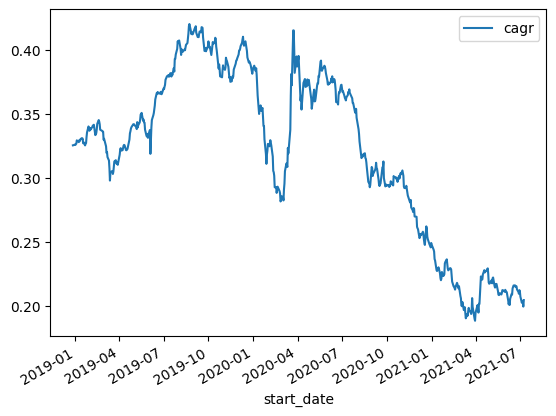

In [164]:
# Look at individual 5yr rolling CAGR values for the top fund, by start date -- see if they're clustered around a specific era
top_fund_code = risk_return_df[risk_return_df['window_years']==5].sort_values('mean', ascending=False).iloc[0]['Scheme_Code']
sample = long_df[(long_df['Scheme_Code']==top_fund_code) & (long_df['window_years']==5)].sort_values('start_date')
sample[['start_date','cagr']].describe()
sample.plot(x='start_date', y='cagr')

In [165]:
# For each fund, get the full NAV date range and how many years of history it spans
history_span = nav_selected.groupby('Scheme_Code')['date'].agg(['min', 'max'])
history_span['years_of_history'] = (history_span['max'] - history_span['min']).dt.days / 365.25
history_span = history_span.merge(name_lookup, on='Scheme_Code', how='left')

# Flag funds whose entire history starts after 2018 -- meaning even their
# longest possible rolling windows can never include a pre-2018 period
history_span['starts_after_2018'] = history_span['min'] > pd.Timestamp('2018-01-01')

print(history_span['years_of_history'].describe())
print("\nFunds with history entirely after 2018:", history_span['starts_after_2018'].sum())
history_span.sort_values('years_of_history').head(15)
# More targeted: for window_years=5 specifically, which funds have their
# valid 5yr rolling windows *entirely* clustered inside 2019-2024?
w5 = long_df[long_df['window_years'] == 5]
window_span_5yr = w5.groupby('Scheme_Code')['start_date'].agg(['min', 'max', 'count'])
window_span_5yr['fully_inside_bull_run'] = (
    (window_span_5yr['min'] >= pd.Timestamp('2018-01-01'))
)
window_span_5yr = window_span_5yr.merge(name_lookup, on='Scheme_Code', how='left')

print("5yr-window funds fully starting after 2018:", window_span_5yr['fully_inside_bull_run'].sum(), "out of", len(window_span_5yr))
window_span_5yr.sort_values('min', ascending=False).head(15)

count    138.000000
mean       8.694263
std        5.070620
min        0.229979
25%        3.632444
50%       10.717317
75%       13.516769
max       13.519507
Name: years_of_history, dtype: float64

Funds with history entirely after 2018: 63
5yr-window funds fully starting after 2018: 17 out of 92


,Scheme_Code,min,max,count,fully_inside_bull_run,Scheme_NAV_Name
91,148978,2021-06-24,2021-07-09,12,True,Kotak Nifty 50 Index Fund - Direct Plan-Growth
90,148755,2021-03-18,2021-07-09,74,True,Mirae Asset Corporate Bond Fund Direct Growth ...
89,148729,2021-02-25,2021-07-09,88,True,Mahindra Manulife Short Duration Fund - Direct...
88,148507,2020-10-12,2021-07-09,185,True,Sundaram Large Cap Fund (Formerly Known as Sun...
87,147946,2020-02-26,2021-07-09,339,True,BANDHAN SMALL CAP FUND - DIRECT PLAN GROWTH
86,147689,2019-09-25,2020-03-20,120,True,Nippon India Aggressive Hybrid Fund - Segregat...
84,147445,2019-07-30,2021-07-09,480,True,Mirae Asset Midcap Fund- Direct Growth Option
85,147446,2019-07-23,2021-07-09,485,True,Mahindra Manulife Aggressive Hybrid Fund - Dir...
81,146130,2019-02-19,2021-07-09,588,True,CANARA ROBECO SMALL CAP FUND - DIRECT PLAN - G...
82,146196,2019-02-14,2021-07-09,592,True,Edelweiss Small Cap Fund - Direct Plan - Growth


In [169]:
history_span = nav_selected.groupby('Scheme_Code')['date'].agg(['min', 'max']).reset_index()
history_span['starts_before_2018'] = history_span['min'] < pd.Timestamp('2018-01-01')

risk_return_df = results_df.rename(columns={'mean_cagr': 'mean', 'min_cagr': 'min'})
risk_return_df = risk_return_df.merge(name_lookup, on='Scheme_Code', how='left')
risk_return_df = risk_return_df.rename(columns={'Scheme_NAV_Name': 'fund'})
risk_return_df = risk_return_df.merge(history_span[['Scheme_Code', 'starts_before_2018']], on='Scheme_Code', how='left')

risk_return_df_filtered = risk_return_df[risk_return_df['starts_before_2018'] == True].copy()

print(f"After filter: {risk_return_df_filtered['Scheme_Code'].nunique()} funds")
print(risk_return_df_filtered['min'].isna().sum())  # confirm 'min' survived this time

After filter: 75 funds
0


In [175]:
advise_investment(risk_return_df_filtered, principal=100000, years=5, penalty=1.0, risk_column='min', n=3)

Top 3 fund(s) recommened for 5 years at penalty weight 1.0 (risk measure: min):

  #1: Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option
      Expected Cagr=0.2455 
      Worst Case Cagr return (min)=0.0234
      Score= 0.2455

  #2: Edelweiss Mid Cap Fund - Direct Plan - Growth Option
      Expected Cagr=0.2381 
      Worst Case Cagr return (min)=0.1192
      Score= 0.2381

  #3: Axis Small Cap Fund - Direct Plan - Growth
      Expected Cagr=0.2158 
      Worst Case Cagr return (min)=0.0497
      Score= 0.2158


Projected value of Rs100000 over 5 years, per recommended fund:
  Nippon India Small Cap Fund - Direct Plan Growth Plan - Bonus Option: approx Rs299745.50
  Edelweiss Mid Cap Fund - Direct Plan - Growth Option: approx Rs290909.19
  Axis Small Cap Fund - Direct Plan - Growth: approx Rs265683.95


,fund,mean,min,score
0,Nippon India Small Cap Fund - Direct Plan Grow...,0.245520,0.023438,0.245520
1,Edelweiss Mid Cap Fund - Direct Plan - Growth ...,0.238088,0.119172,0.238088
2,Axis Small Cap Fund - Direct Plan - Growth,0.215831,0.049742,0.215831


2013-01-03 00:00:00 2021-07-09 00:00:00


<Axes: xlabel='start_date'>

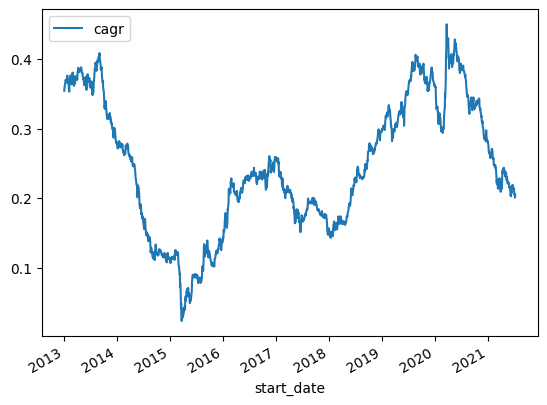

In [174]:
# Check the actual spread of 5yr window start dates for Nippon India Small Cap
top_code = risk_return_df_filtered[
    risk_return_df_filtered['fund'].str.contains('Nippon India Small Cap', case=False, na=False)
]['Scheme_Code'].iloc[0]

nippon_5yr = long_df[(long_df['Scheme_Code'] == top_code) & (long_df['window_years'] == 5)].sort_values('start_date')
print(nippon_5yr['start_date'].min(), nippon_5yr['start_date'].max())
nippon_5yr.plot(x='start_date', y='cagr')